# Differential analysis of samples

## Loads libraries

In [1]:
library(DESeq2)
library(tidyverse)
library(ggplot2)
library(ggrepel)

Loading required package: S4Vectors
Loading required package: stats4
Loading required package: BiocGenerics
Loading required package: generics

Attaching package: ‘generics’

The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff, setequal, union


Attaching package: ‘BiocGenerics’

The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs

The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind, colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find, get, grep, grepl, is.unsorted,
    lapply, Map, mapply, match, mget, order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank, rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Attaching package: ‘S4Vectors’

The following object is masked from ‘package:utils’:

    findMatches

The following objects are masked fro

### Read in dataframes 

In [2]:
counts_data <- read.table("gene_counts.tsv", header=TRUE, row.names=1, sep="\t")
sample_info <- read.table("sample_metadata.tsv", header=TRUE, row.names=1, sep="\t")

### Check order and matching column names names

In [3]:
all(colnames(counts_data) %in% rownames(sample_info))
all(colnames(counts_data) == rownames(sample_info))
sample_info <- sample_info[colnames(counts_data), , drop=FALSE]

### Constructs the DEseq dataframe 

In [4]:
dds <- DESeqDataSetFromMatrix(
  countData = counts_data,
  colData = sample_info,
  design = ~ condition
)

Warning message:
In DESeqDataSet(se, design = design, ignoreRank) :
  some variables in design formula are characters, converting to factors


### Pre filtering to reduce very low reads

In [5]:
keep <- rowSums(counts(dds)) >= 10
dds <- dds[keep,]

### Sets the normal samples as the reference

In [6]:
dds$condition <- relevel(dds$condition, ref = "normal")

### Run DESeq2 and save results

In [7]:
dds$condition <- relevel(dds$condition, ref = "normal")
dds <- DESeq(dds)
res <- results(dds)
write.csv(as.data.frame(res), file="differential_gene_results.csv")

estimating size factors
estimating dispersions
gene-wise dispersion estimates
mean-dispersion relationship
final dispersion estimates
fitting model and testing


### Summerise results

In [8]:
summary(res)
table(res$padj < 0.05)


out of 1000 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 49, 4.9%
LFC < 0 (down)     : 53, 5.3%
outliers [1]       : 0, 0%
low counts [2]     : 0, 0%
(mean count < 16)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results




FALSE  TRUE 
  903    97 

### Creates a factor of the gene targets from CUT&RUN analysis

In [9]:
target_genes <- c("GENE_0002", "GENE_0018", "GENE_0034", "GENE_0035", "GENE_0038")

### Takes only the cut and run genes from the target gene file

In [23]:
res_targets <- res[rownames(res) %in% target_genes, ]
table(res$padj < 0.05 & abs(res$log2FoldChange) > 1)


FALSE  TRUE 
  947    53 

### Searches for these genes in significant genes list

In [ ]:
significant_targets <- res_targets[which(res_targets$padj < 0.05), ]
print(significant_targets)

log2 fold change (MLE): condition mutant vs normal 
Wald test p-value: condition mutant vs normal 
DataFrame with 4 rows and 6 columns
           baseMean log2FoldChange     lfcSE      stat      pvalue        padj
          <numeric>      <numeric> <numeric> <numeric>   <numeric>   <numeric>
GENE_0002   57.9527      -0.891093  0.198582  -4.48727 7.21405e-06 1.16356e-04
GENE_0018  658.1941       1.206611  0.169214   7.13068 9.98772e-13 3.56704e-11
GENE_0034   85.9679      -1.387654  0.189929  -7.30619 2.74822e-13 1.01786e-11
GENE_0035  105.1448       1.571377  0.206611   7.60548 2.83844e-14 1.18268e-12


### Identify significant and not signficant genes

In [21]:
res$status <- "Not Significant"
res$status[res$padj < 0.05 & abs(res$log2FoldChange) > 0.5] <- "Significant"
res$status <- factor(res$status, levels = c("Not Significant", "Significant"))

### Creates a list of the significant target gene names

In [22]:
significant_target_list <- c("GENE_0002","GENE_0018","GENE_0034","GENE_0035")
res$label <- ifelse(rownames(res) %in% significant_target_list, rownames(res), NA)

### Volcano plot 
Positron autocomplete assisted with the themeing

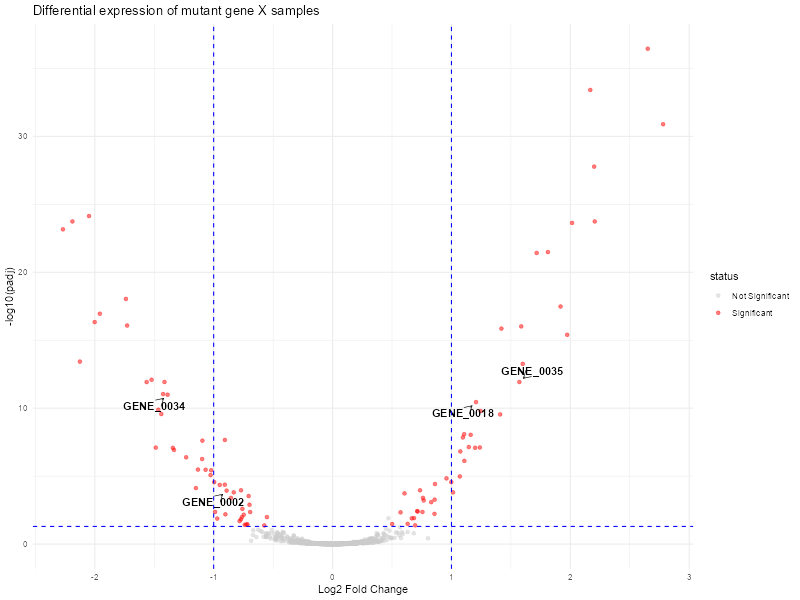

In [20]:
ggplot(res, aes(x = log2FoldChange, y = -log10(padj), color = status)) +
  geom_point(alpha = 0.5, size = 1.5) +
  scale_color_manual(values = c("Not Significant" = "grey80", "Significant" = "red")) +
  geom_text_repel(aes(label = label),na.rm = TRUE,
  color = "black",
  fontface = "bold",
  arrow = arrow(length = grid::unit(0.015, "npc")),
  segment.color = "black",
  segment.size = 0.3,
  point.padding = 0.3,
  box.padding = 0.4,
  min.segment.length = 0
) +
  theme_minimal() +
  geom_vline(xintercept = c(-1, 1), linetype = "dashed", color = "blue") +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "blue") +
  labs(x = "Log2 Fold Change",
       y = "-log10(padj)") +
  ggtitle("Differential expression of mutant gene X samples")


### PCA Analysis

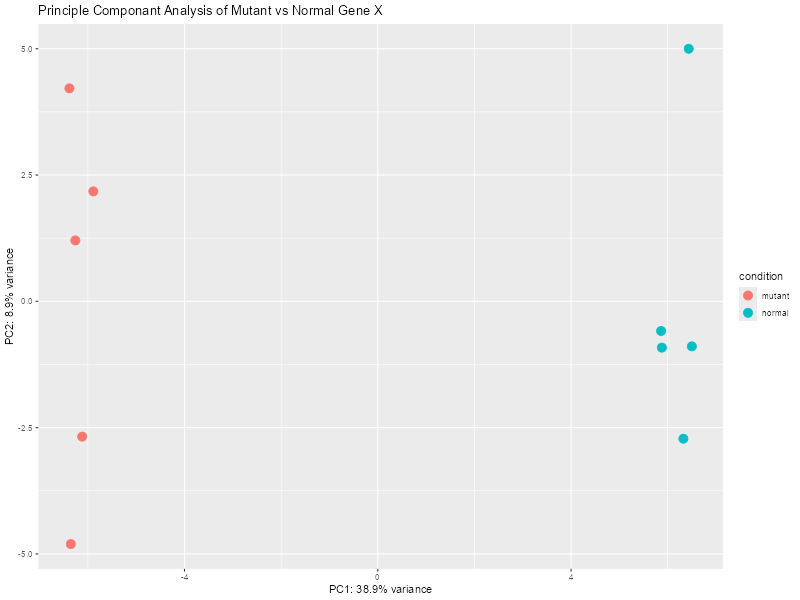

In [15]:

vsd <- vst(dds, blind=FALSE)

pca_data <- t(assay(vsd))
pca_results <- prcomp(pca_data)

percentVar <- pca_results$sdev^2 / sum(pca_results$sdev^2)

plot_df <- data.frame(PC1 = pca_results$x[,1], 
                      PC2 = pca_results$x[,2], 
                      condition = sample_info$condition)

ggplot(plot_df, aes(x = PC1, y = PC2, color = condition)) +
  geom_point(size = 4) +
  xlab(paste0("PC1: ", round(percentVar[1]*100, 1), "% variance")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100, 1), "% variance")) +
  ggtitle("Principle Componant Analysis of Mutant vs Normal Gene X")